In [25]:
# ============================================================
# FRAUD DETECTION - TRANSACTIONAL RISK MONITOR
# Autor: DARIELA RODRIGUEZ FORTIN
# Dataset: Credit Card Fraud Detection (Kaggle - ULB)
# Herramientas: Python · XGBoost · SMOTE · pandasql · Data Studio
# ============================================================

# Librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, average_precision_score,
                             recall_score, precision_score, f1_score)
import xgboost as xgb

# Imbalanced data
from imblearn.over_sampling import SMOTE

# SQL sobre dataframes
import pandasql as ps

print("Todas las librerías cargadas correctamente")
print(f"  pandas     {pd.__version__}")
print(f"  numpy      {np.__version__}")
print(f"  xgboost    {xgb.__version__}")

Todas las librerías cargadas correctamente
  pandas     2.3.3
  numpy      2.0.2
  xgboost    3.1.3


In [26]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

total = len(df)
fraudes = df['Class'].sum()
normales = total - fraudes

print("=" * 45)
print("VISTA GENERAL DEL DATASET")
print("=" * 45)
print(f"  Filas:           {df.shape[0]:,}")
print(f"  Columnas:        {df.shape[1]}")
print(f"  Memoria:         {df.memory_usage().sum() / 1024**2:.1f} MB")
print(f"\n  Total transacciones:    {total:,}")
print(f"  Transacciones normales: {normales:,} ({normales/total*100:.2f}%)")
print(f"  Transacciones fraude:   {fraudes:,}   ({fraudes/total*100:.2f}%)")
print(f"\n  Valores nulos: {df.isnull().sum().sum()}")
print(f"\n  Columnas: {list(df.columns)}")

VISTA GENERAL DEL DATASET
  Filas:           284,807
  Columnas:        31
  Memoria:         67.4 MB

  Total transacciones:    284,807
  Transacciones normales: 284,315 (99.83%)
  Transacciones fraude:   492   (0.17%)

  Valores nulos: 0

  Columnas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [27]:
from datetime import datetime, timedelta

fecha_base = datetime(2024, 1, 15, 0, 0, 0)
df['DateTime'] = df['Time'].apply(
    lambda x: fecha_base + timedelta(seconds=x)
)
df['Hour'] = df['DateTime'].dt.hour
df['Date'] = df['DateTime'].dt.date
df['TimeBlock'] = pd.cut(df['Hour'],
                          bins=[0, 6, 12, 18, 24],
                          labels=['Madrugada','Mañana','Tarde','Noche'],
                          right=False)

print("Fechas simuladas correctamente")
print(f"\n  Rango: {df['DateTime'].min()} → {df['DateTime'].max()}")
print(f"\n  Transacciones por bloque horario:")
print(df.groupby('TimeBlock', observed=True)['Class'].agg(['count','sum']).rename(
    columns={'count':'Total','sum':'Fraudes'}))

Fechas simuladas correctamente

  Rango: 2024-01-15 00:00:00 → 2024-01-16 23:59:52

  Transacciones por bloque horario:
           Total  Fraudes
TimeBlock                
Madrugada  23934      124
Mañana     70912      118
Tarde      96435      134
Noche      93526      116


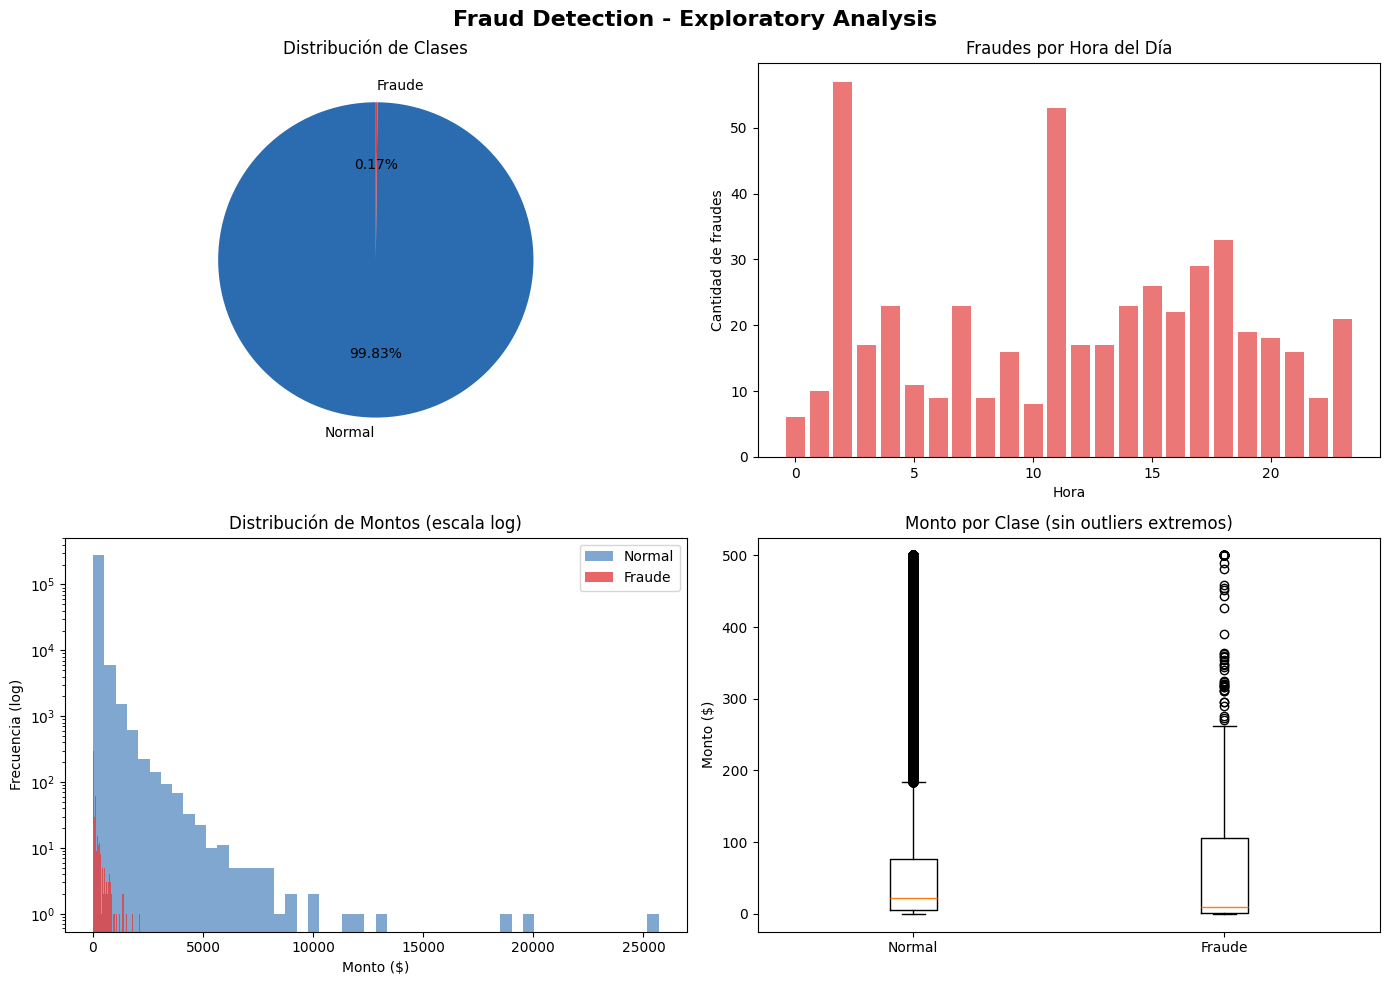

Visualización guardada como eda_overview.png


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fraud Detection - Exploratory Analysis', fontsize=16, fontweight='bold')

# 1. Distribución de clases
axes[0,0].pie(
    [normales, fraudes],
    labels=['Normal', 'Fraude'],
    colors=['#2B6CB0', '#E53E3E'],
    autopct='%1.2f%%',
    startangle=90
)
axes[0,0].set_title('Distribución de Clases')

# 2. Fraudes por hora
fraudes_hora = df[df['Class']==1].groupby('Hour').size()
axes[0,1].bar(fraudes_hora.index, fraudes_hora.values, color='#E53E3E', alpha=0.7)
axes[0,1].set_title('Fraudes por Hora del Día')
axes[0,1].set_xlabel('Hora')
axes[0,1].set_ylabel('Cantidad de fraudes')

# 3. Distribución de montos (log scale)
axes[1,0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6,
               color='#2B6CB0', label='Normal', log=True)
axes[1,0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.8,
               color='#E53E3E', label='Fraude', log=True)
axes[1,0].set_title('Distribución de Montos (escala log)')
axes[1,0].set_xlabel('Monto ($)')
axes[1,0].set_ylabel('Frecuencia (log)')
axes[1,0].legend()

# 4. Boxplot monto por clase
axes[1,1].boxplot(
    [df[df['Class']==0]['Amount'].clip(0, 500),
     df[df['Class']==1]['Amount'].clip(0, 500)],
    labels=['Normal', 'Fraude']
)
axes[1,1].set_title('Monto por Clase (sin outliers extremos)')
axes[1,1].set_ylabel('Monto ($)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualización guardada como eda_overview.png")

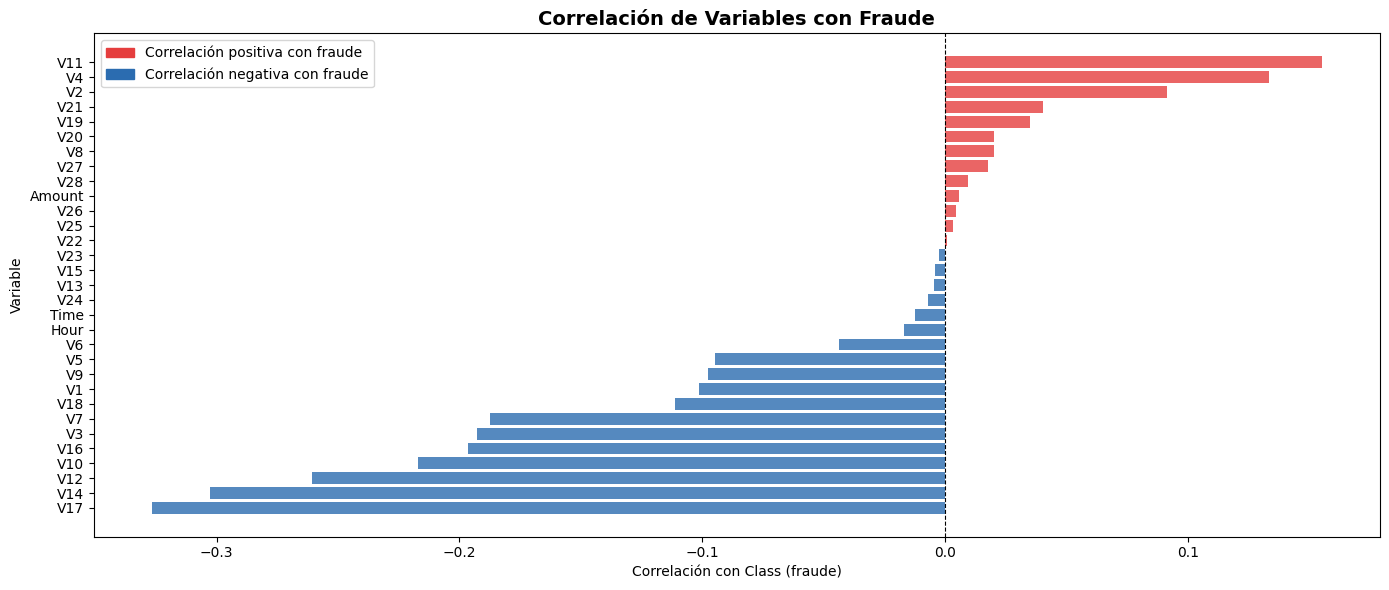

Visualización guardada como correlaciones_fraude.png


In [29]:
fig, ax = plt.subplots(figsize=(14, 6))

# Correlación de cada variable con la clase (fraude)
correlaciones = df.drop(columns=['DateTime','Date','TimeBlock']).corr()['Class'].drop('Class').sort_values()

colores = ['#E53E3E' if x > 0 else '#2B6CB0' for x in correlaciones]

ax.barh(correlaciones.index, correlaciones.values, color=colores, alpha=0.8)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Correlación de Variables con Fraude', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlación con Class (fraude)')
ax.set_ylabel('Variable')

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [Patch(color='#E53E3E', label='Correlación positiva con fraude'),
           Patch(color='#2B6CB0', label='Correlación negativa con fraude')]
ax.legend(handles=leyenda)

plt.tight_layout()
plt.savefig('correlaciones_fraude.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualización guardada como correlaciones_fraude.png")

In [30]:
!pip install pandasql -q
print("pandasql listo")

pandasql listo


In [31]:
# ============================================================
# SECCIÓN 4 — ANÁLISIS SQL
# ============================================================

import pandasql as ps

# Query 1: Tasa de fraude por bloque horario
q1 = """
SELECT 
    TimeBlock,
    COUNT(*) as total_transacciones,
    SUM(Class) as fraudes,
    ROUND(AVG(Class) * 100, 3) as tasa_fraude_pct,
    ROUND(AVG(Amount), 2) as monto_promedio
FROM df
GROUP BY TimeBlock
ORDER BY tasa_fraude_pct DESC
"""
print("=== Tasa de fraude por bloque horario ===")
print(ps.sqldf(q1, locals()))

=== Tasa de fraude por bloque horario ===
   TimeBlock  total_transacciones  fraudes  tasa_fraude_pct  monto_promedio
0  Madrugada                23934      124            0.518           61.25
1     Mañana                70912      118            0.166           98.25
2      Tarde                96435      134            0.139          102.06
3      Noche                93526      116            0.124           73.64


In [32]:
# Query 2: Fraudes por rango de monto
q2 = """
SELECT 
    CASE 
        WHEN Amount < 50 THEN '1. Menos de $50'
        WHEN Amount < 200 THEN '2. $50 a $200'
        WHEN Amount < 500 THEN '3. $200 a $500'
        ELSE '4. Mas de $500'
    END as rango_monto,
    COUNT(*) as total_fraudes,
    ROUND(AVG(Amount), 2) as monto_promedio,
    ROUND(SUM(Amount), 2) as monto_total_perdido
FROM df
WHERE Class = 1
GROUP BY rango_monto
ORDER BY rango_monto
"""
print("=== Fraudes por rango de monto ===")
print(ps.sqldf(q2, locals()))

=== Fraudes por rango de monto ===
       rango_monto  total_fraudes  monto_promedio  monto_total_perdido
0  1. Menos de $50            305            6.64              2023.93
1    2. $50 a $200            102          109.20             11138.15
2   3. $200 a $500             50          315.42             15770.99
3   4. Mas de $500             35          891.28             31194.90


In [33]:
# Query 3: Comparación estadística fraude vs normal
q3 = """
SELECT
    CASE WHEN Class = 1 THEN 'Fraude' ELSE 'Normal' END as tipo,
    COUNT(*) as cantidad,
    ROUND(AVG(Amount), 2) as monto_promedio,
    ROUND(MIN(Amount), 2) as monto_minimo,
    ROUND(MAX(Amount), 2) as monto_maximo,
    ROUND(SUM(Amount), 2) as monto_total
FROM df
GROUP BY Class
"""
print("=== Estadísticas comparativas fraude vs normal ===")
print(ps.sqldf(q3, locals()))

=== Estadísticas comparativas fraude vs normal ===
     tipo  cantidad  monto_promedio  monto_minimo  monto_maximo  monto_total
0  Normal    284315           88.29           0.0      25691.16  25102462.04
1  Fraude       492          122.21           0.0       2125.87     60127.97


In [34]:
# ============================================================
# SECCIÓN 5 — PREPROCESAMIENTO
# ============================================================

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

feature_cols = [c for c in df.columns
                if c not in ['Class', 'Amount', 'Time', 'DateTime',
                              'Date', 'TimeBlock', 'Hour']]

X = df[feature_cols]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Preprocesamiento completo")
print(f"\n  Features usadas: {len(feature_cols)}")
print(f"  Train: {X_train.shape} | Fraudes en train: {y_train.sum()}")
print(f"  Test:  {X_test.shape}  | Fraudes en test:  {y_test.sum()}")

Preprocesamiento completo

  Features usadas: 30
  Train: (227845, 30) | Fraudes en train: 394
  Test:  (56962, 30)  | Fraudes en test:  98


In [35]:
# ============================================================
# SECCIÓN 6 — BALANCEO CON SMOTE
# ============================================================

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("SMOTE aplicado correctamente")
print(f"\n  ANTES:")
print(f"    Normales: {(y_train==0).sum():,}")
print(f"    Fraudes:  {y_train.sum():,}")
print(f"\n  DESPUÉS:")
print(f"    Normales: {(y_train_sm==0).sum():,}")
print(f"    Fraudes:  {y_train_sm.sum():,}")
print(f"\n  Ratio final: 1:1 ")

SMOTE aplicado correctamente

  ANTES:
    Normales: 227,451
    Fraudes:  394

  DESPUÉS:
    Normales: 227,451
    Fraudes:  227,451

  Ratio final: 1:1 


In [36]:
# ============================================================
# SECCIÓN 7 — ENTRENAMIENTO DE MODELOS
# ============================================================

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': xgb.XGBClassifier(scale_pos_weight=577, eval_metric='aucpr',
                                   random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    
    if nombre == 'XGBoost':
        modelo.fit(X_train, y_train)
    else:
        modelo.fit(X_train_sm, y_train_sm)
    
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:,1]
    
    resultados[nombre] = {
        'recall': recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'avg_precision': average_precision_score(y_test, y_proba),
        'modelo': modelo
    }
    print(f"   {nombre} listo — Recall: {resultados[nombre]['recall']:.3f}\n")

print("=" * 45)
print("RESUMEN DE MODELOS")
print("=" * 45)
for nombre, res in resultados.items():
    print(f"{nombre}")
    print(f"  Recall:    {res['recall']:.3f}")
    print(f"  Precision: {res['precision']:.3f}")
    print(f"  F1:        {res['f1']:.3f}\n")

Entrenando Logistic Regression...
   Logistic Regression listo — Recall: 0.918

Entrenando Random Forest...
   Random Forest listo — Recall: 0.806

Entrenando XGBoost...
   XGBoost listo — Recall: 0.847

RESUMEN DE MODELOS
Logistic Regression
  Recall:    0.918
  Precision: 0.058
  F1:        0.109

Random Forest
  Recall:    0.806
  Precision: 0.814
  F1:        0.810

XGBoost
  Recall:    0.847
  Precision: 0.883
  F1:        0.865



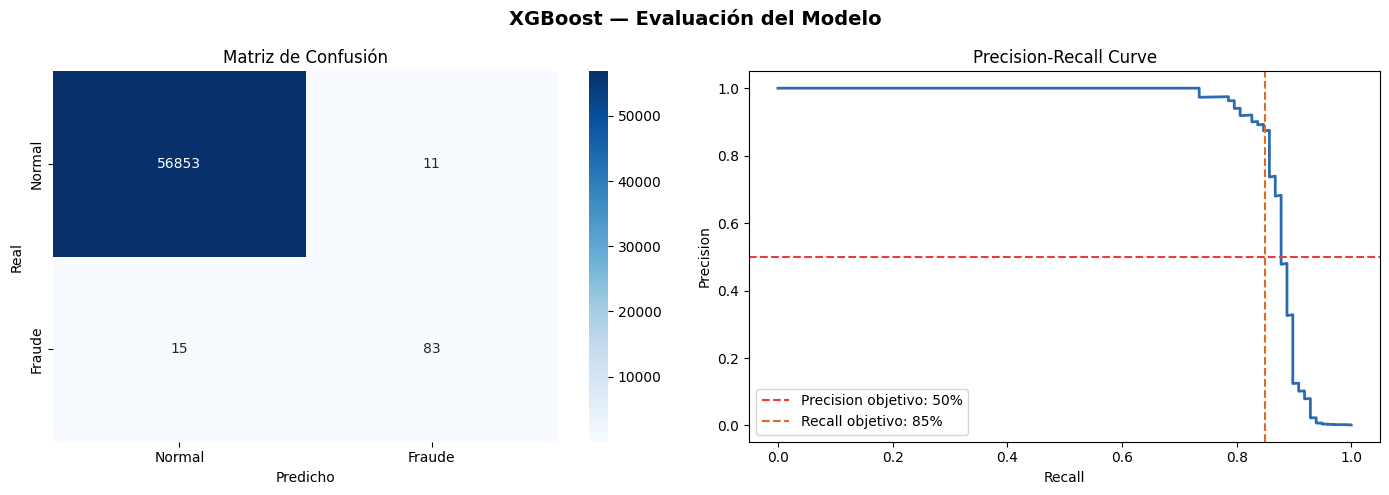

Evaluación visual guardada


In [37]:
# ============================================================
# SECCIÓN 8 — EVALUACIÓN VISUAL
# ============================================================

modelo_final = resultados['XGBoost']['modelo']
y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost — Evaluación del Modelo', fontsize=14, fontweight='bold')

# 1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraude'],
            yticklabels=['Normal','Fraude'],
            ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# 2. Precision-Recall curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall_curve, precision_curve, color='#2B6CB0', linewidth=2)
axes[1].axhline(y=0.5, color='#E53E3E', linestyle='--', label='Precision objetivo: 50%')
axes[1].axvline(x=0.85, color='#DD6B20', linestyle='--', label='Recall objetivo: 85%')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig('modelo_evaluacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Evaluación visual guardada")

In [38]:
# ============================================================
# SECCIÓN 9 — GENERAR CSV PARA DASHBOARD
# ============================================================

df_test = X_test.copy()
df_test['Class_real'] = y_test.values
df_test['Score_Riesgo'] = (modelo_final.predict_proba(X_test)[:,1] * 100).round(1)
df_test['Prediccion'] = modelo_final.predict(X_test)

df_test['Nivel_Alerta'] = pd.cut(df_test['Score_Riesgo'],
                                  bins=[0, 50, 70, 90, 100],
                                  labels=['Normal','Bajo','Medio','Alto'])
df_test['DateTime'] = df.loc[X_test.index, 'DateTime'].values
df_test['Hour'] = df.loc[X_test.index, 'Hour'].values
df_test['TimeBlock'] = df.loc[X_test.index, 'TimeBlock'].values
df_test['Amount'] = df.loc[X_test.index, 'Amount'].values
df_test['Transaction_ID'] = ['TXN-' + str(i).zfill(5) for i in range(len(df_test))]

df_dashboard = df_test[['Transaction_ID','DateTime','Hour','TimeBlock',
                          'Amount','Score_Riesgo','Nivel_Alerta',
                          'Class_real','Prediccion']].copy()

df_dashboard.to_csv('fraud_dashboard_data.csv', index=False)

print(f" CSV exportado correctamente")
print(f"\n  Total filas:     {len(df_dashboard):,}")
print(f"  Fraudes reales:  {df_dashboard['Class_real'].sum()}")
print(f"  Alertas altas:   {(df_dashboard['Nivel_Alerta']=='Alto').sum()}")
print(f"  Alertas medias:  {(df_dashboard['Nivel_Alerta']=='Medio').sum()}")
print(f"\nPrimeras alertas altas:")
print(df_dashboard[df_dashboard['Nivel_Alerta']=='Alto'][
    ['Transaction_ID','DateTime','Amount','Score_Riesgo','Nivel_Alerta','Class_real']
].head())

 CSV exportado correctamente

  Total filas:     56,962
  Fraudes reales:  98
  Alertas altas:   89
  Alertas medias:  2

Primeras alertas altas:
       Transaction_ID            DateTime  Amount  Score_Riesgo Nivel_Alerta  \
190263      TXN-00165 2024-01-16 11:45:59    0.76     98.099998         Alto   
77348       TXN-00840 2024-01-15 15:50:07    0.01    100.000000         Alto   
102442      TXN-01146 2024-01-15 18:56:47    1.00    100.000000         Alto   
14920       TXN-02777 2024-01-15 07:16:57    1.00     98.000000         Alto   
119781      TXN-03287 2024-01-15 20:59:41  124.53     99.500000         Alto   

        Class_real  
190263           0  
77348            1  
102442           1  
14920            0  
119781           1  
